# Predicción de clientes aptos para tarjeta de crédito (CreditCard)
Este notebook utiliza el dataset **UniversalBank.csv** para entrenar modelos **SVM** con distintos kernels (linear, RBF/Gaussian, polynomial, sigmoid) para predecir la variable `CreditCard` (1 = cliente apto para tarjeta de crédito, 0 = no).

Se incluyen los pasos:
1. Carga y exploración inicial
2. Limpieza de datos (nulos y columnas irrelevantes)
3. Análisis de correlaciones
4. Preparación de datos y escalado
5. Entrenamiento de modelos SVM
6. Comparación de métricas
7. Visualización de hiperplanos (lineal y RBF en 2D PCA)
8. Notas y sugerencias


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA


In [ ]:

# 1) Cargar dataset
df = pd.read_csv("UniversalBank.csv")
df.head()


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:

# 2) Verificar valores nulos
print("Nulos por columna:\n", df.isna().sum())


Nulos por columna:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [ ]:
# 3) Quitar columnas ID y ZIP
drop_cols = [c for c in ["ID","Zip Code","ZIP Code"] if c in df.columns]
df = df.drop(columns=drop_cols)
print("Columnas eliminadas:", drop_cols)

Columnas eliminadas: ['ID', 'ZIP Code']


/tmp/ipython-input-175520177.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


NameError: name 'scatter_matrix' is not defined

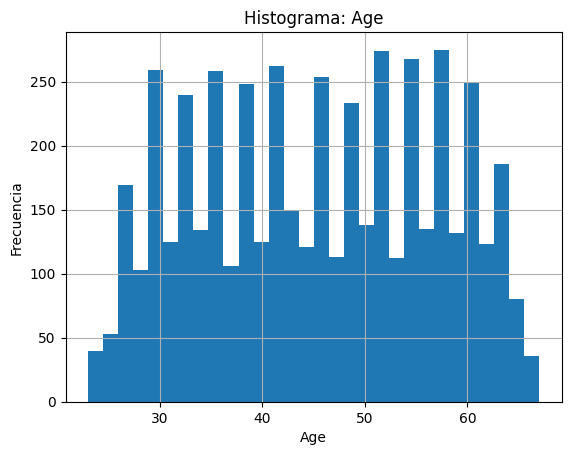

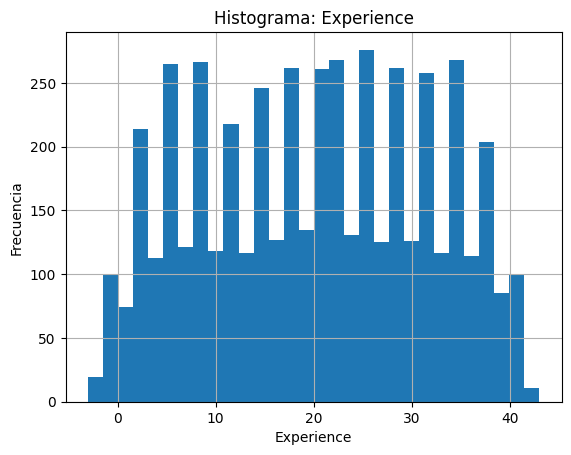

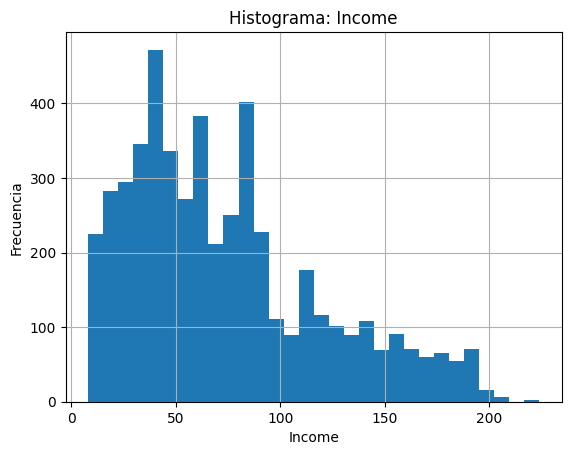

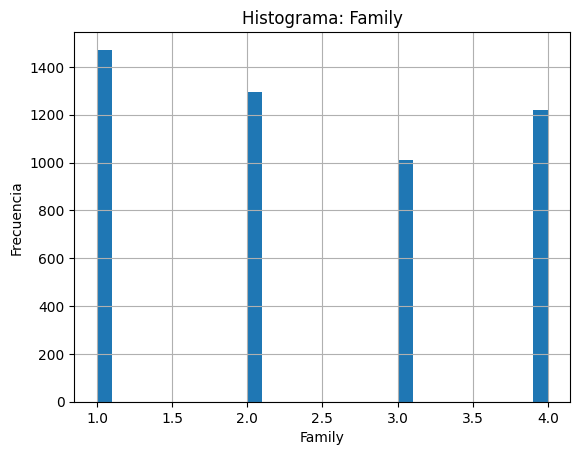

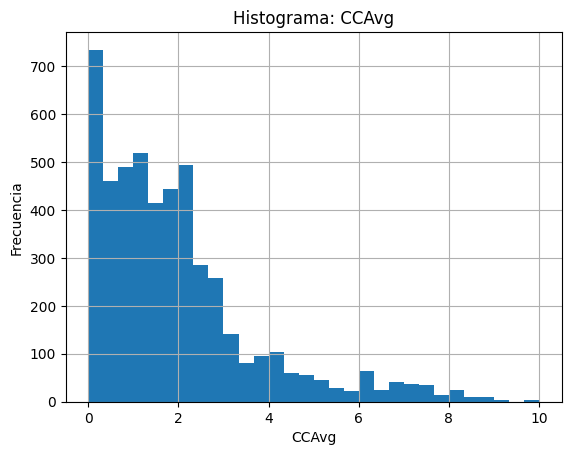

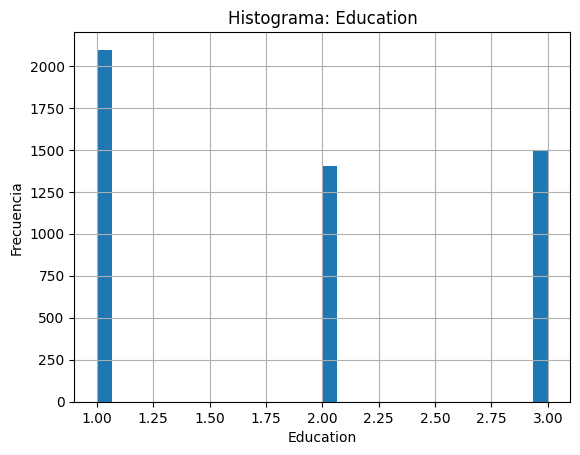

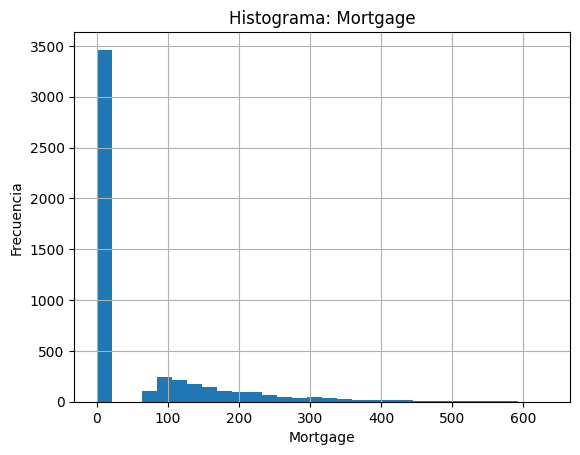

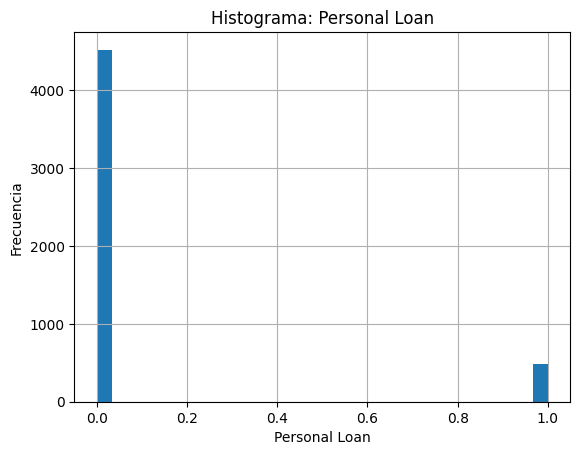

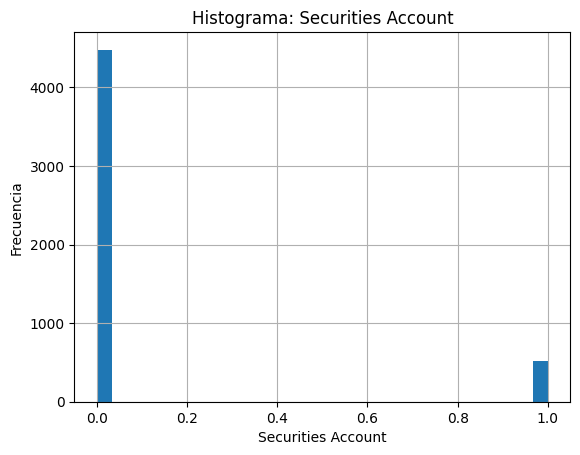

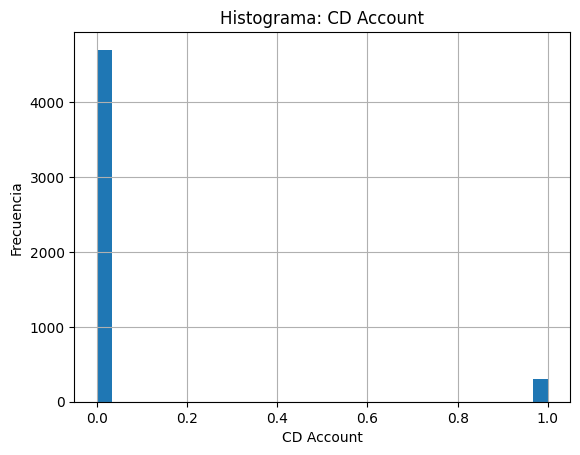

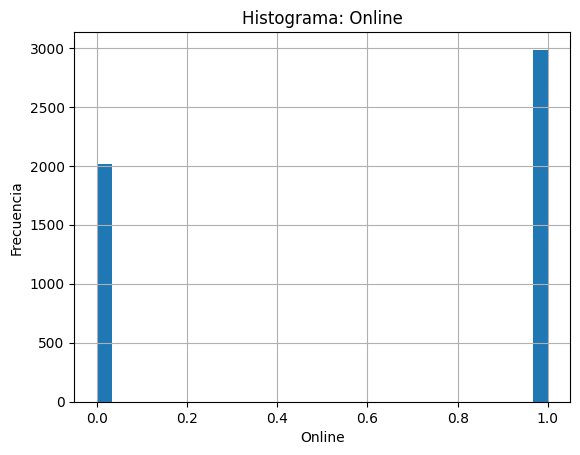

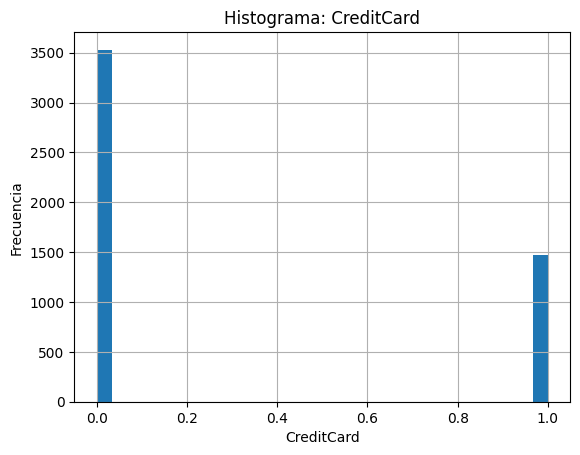

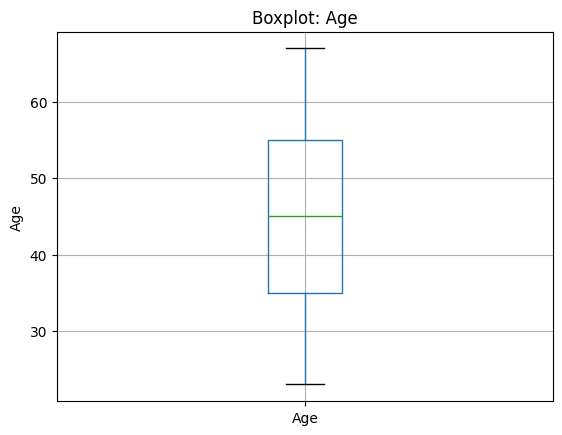

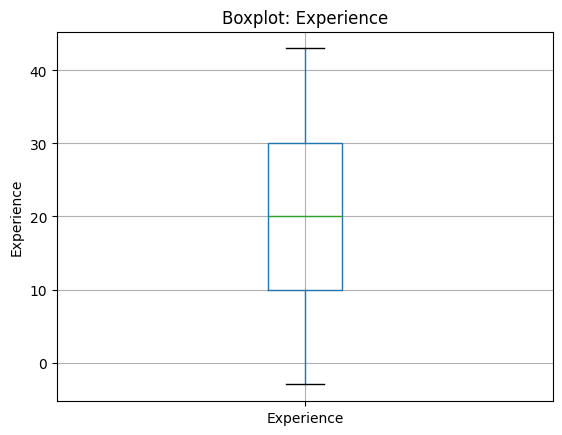

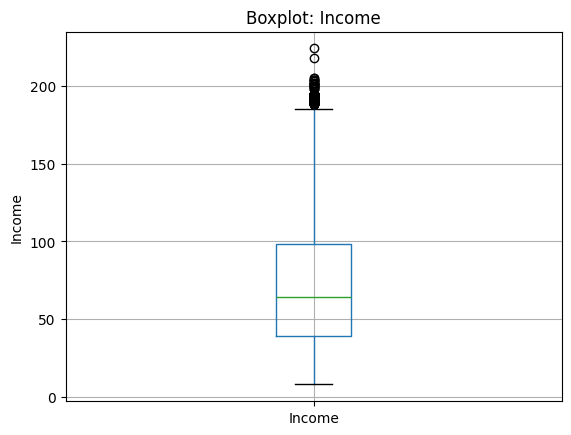

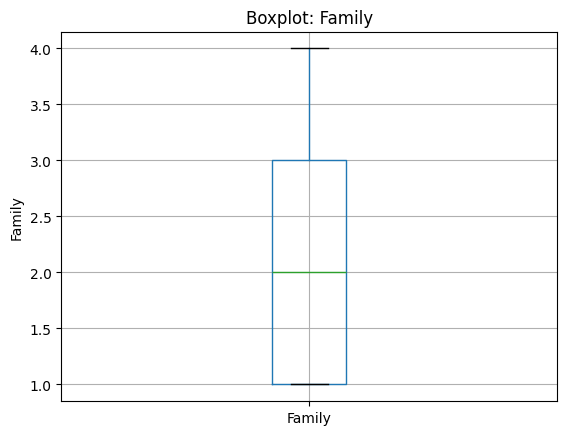

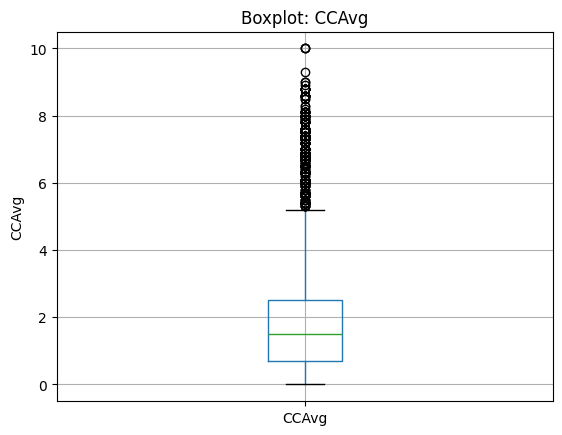

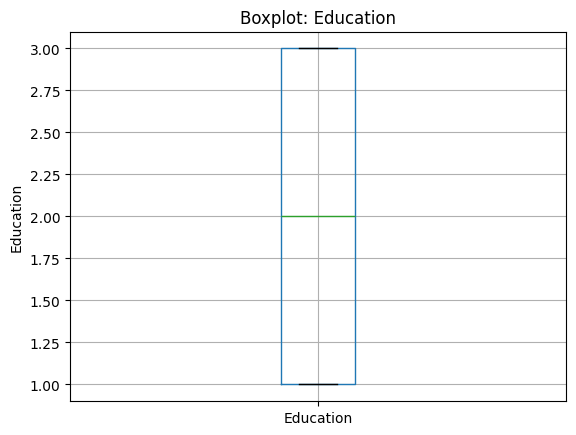

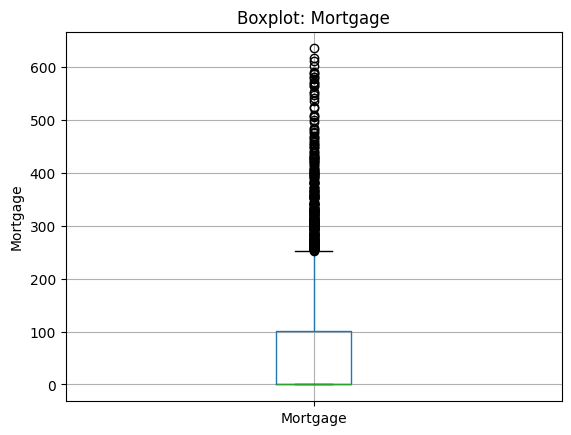

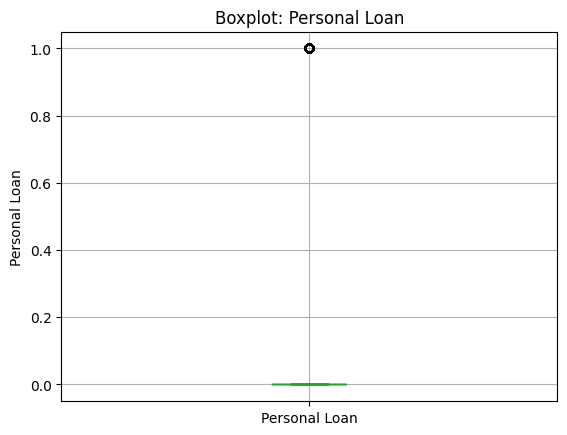

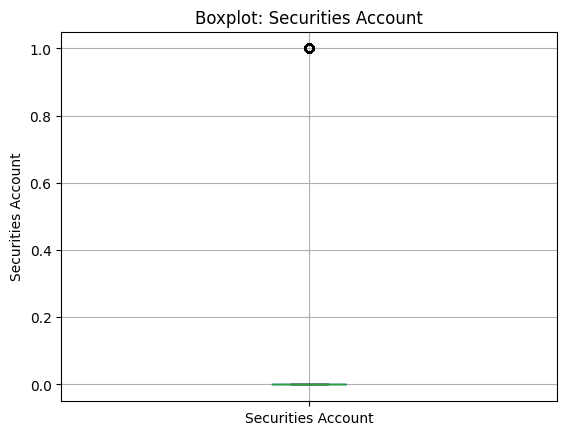

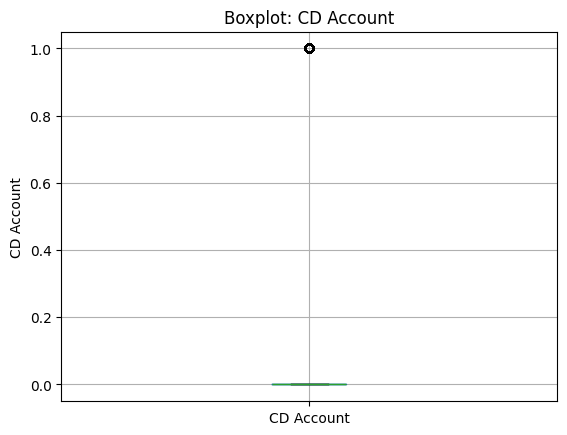

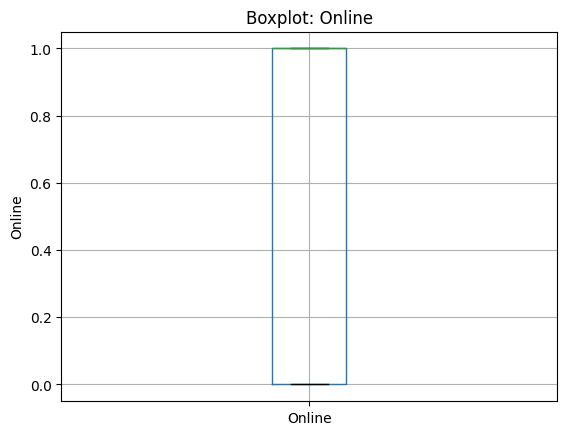

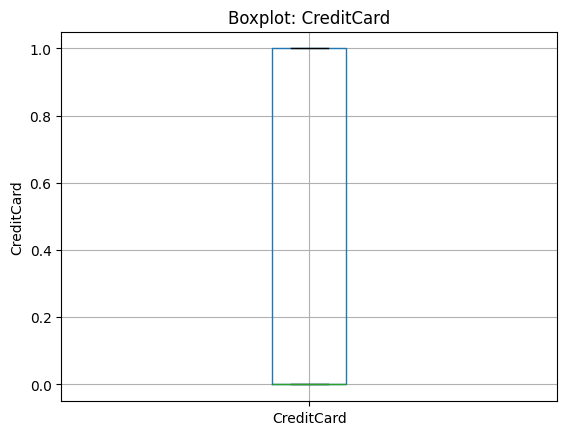

<Figure size 640x480 with 0 Axes>

In [ ]:
shape_info = f"Shape: {df.shape[0]} rows x {df.shape[1]} columns"
dtypes_info = df.dtypes.astype(str)
missing_info = df.isna().sum().sort_values(ascending=False)
basic_stats = df.describe()



# ---------- 4) Exploratory charts ----------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]

# 4.a) Histograms (numéricas)
for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histograma: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")


# 4.b) Boxplots (numéricas)
for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)


# 4.c) Barras (categóricas: top 15 categorías)
for col in non_numeric_cols:
    counts = df[col].astype(str).value_counts().head(15)
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Frecuencias (Top 15): {col}")
    plt.xlabel(col)
    plt.ylabel("Conteo")


# 4.d) Matriz de dispersión (hasta 6 numéricas por legibilidad; elegir por varianza descendente)
scatter_cols = []
if len(numeric_cols) > 0:
    variances = df[numeric_cols].var(numeric_only=True).sort_values(ascending=False)
    scatter_cols = list(variances.head(min(6, len(variances))).index)

if len(scatter_cols) >= 2:
    plt.figure()
    # Pandas genera múltiples subplots internamente, pero se renderiza como una figura (cumple "una figura por gráfico")
    scatter_matrix(df[scatter_cols], figsize=(10, 10), diagonal='hist')
    plt.suptitle("Matriz de dispersión (top por varianza)", y=1.02)
    save_current_fig(f"scatter_matrix_topvar.png")

# 4.e) Mapa de calor de correlación (numéricas)
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr.values, aspect='auto')
    plt.title("Mapa de calor de correlación")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    save_current_fig("corr_heatmap.png")





In [ ]:

# 4) Definir target como CreditCard
target = "CreditCard"
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]
print("Target:", target)
print("Distribución de clases:", y.value_counts().to_dict())


Target: CreditCard
Distribución de clases: {0: 3530, 1: 1470}


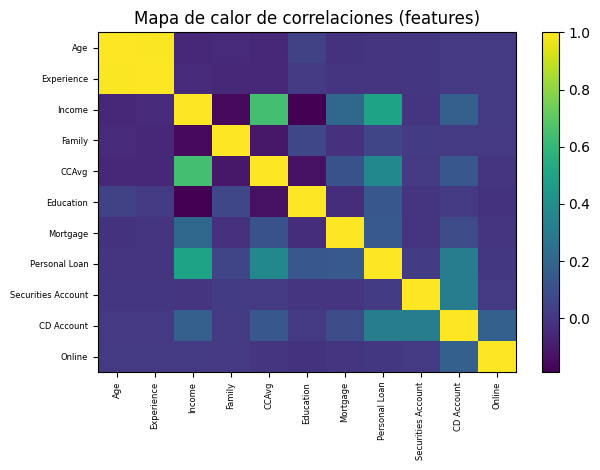

In [ ]:

# 5) Mapa de calor de correlaciones
corr = X.corr()
plt.figure()
plt.imshow(corr.values, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
plt.title("Mapa de calor de correlaciones (features)")
plt.tight_layout()
plt.show()


In [ ]:

# 6) Split + escalado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


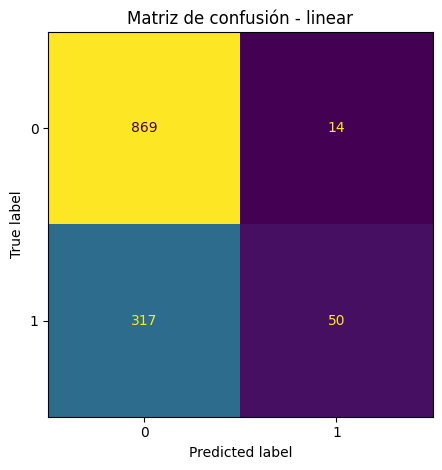

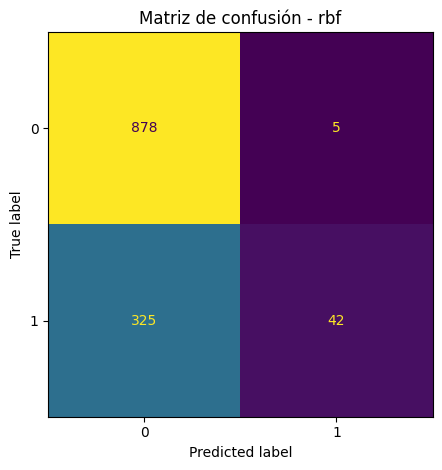

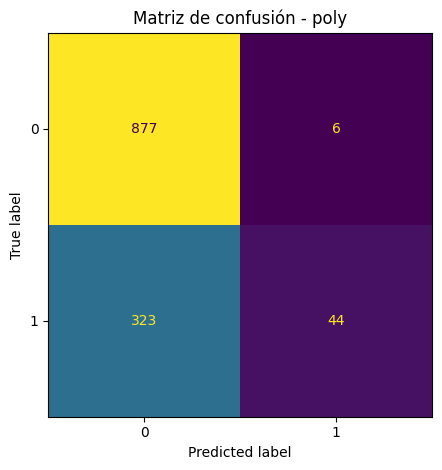

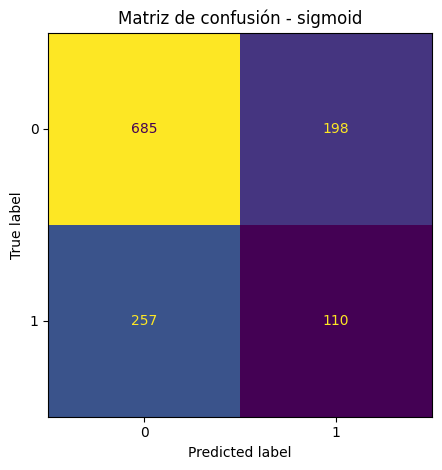

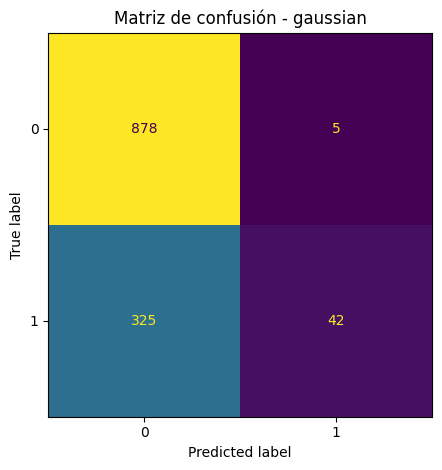

,accuracy,precision,recall,f1,roc_auc
sigmoid,0.6360,0.357143,0.299728,0.325926,0.554909
linear,0.7352,0.781250,0.136240,0.232019,0.558261
poly,0.7368,0.880000,0.119891,0.211031,0.599771
rbf,0.7360,0.893617,0.114441,0.202899,0.590903
gaussian,0.7360,0.893617,0.114441,0.202899,0.590903


In [ ]:

# 7) Modelos SVM con matrices de confusión corregidas
models = {
    "linear":   SVC(kernel="linear", probability=True, random_state=42),
    "rbf":      SVC(kernel="rbf",    probability=True, random_state=42),
    "poly":     SVC(kernel="poly",   degree=3,        probability=True, random_state=42),
    "sigmoid":  SVC(kernel="sigmoid",probability=True, random_state=42),
    "gaussian": SVC(kernel="rbf",    probability=True, random_state=42)
}

rows = {}
cms = {}

for name, clf in models.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:,1]
    rows[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision":precision_score(y_test, y_pred, zero_division=0),
        "recall":   recall_score(y_test, y_pred, zero_division=0),
        "f1":       f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":  roc_auc_score(y_test, y_proba)
    }
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    cms[name] = cm

    # Matriz de confusión con etiquetas 0 y 1
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(colorbar=False)
    plt.title(f"Matriz de confusión - {name}")
    plt.tight_layout()
    plt.show()

metrics = pd.DataFrame(rows).T.sort_values("f1", ascending=False)
metrics


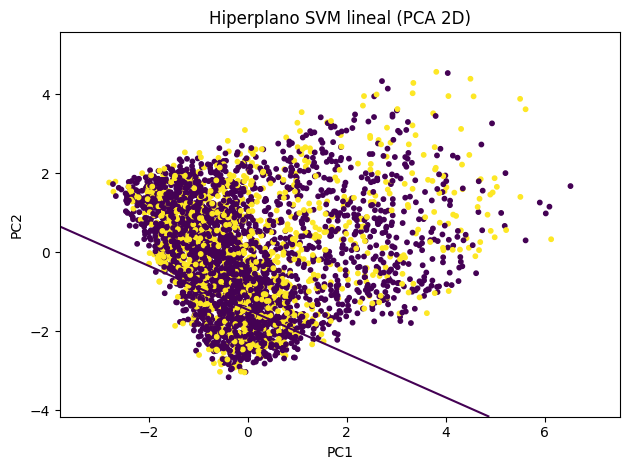

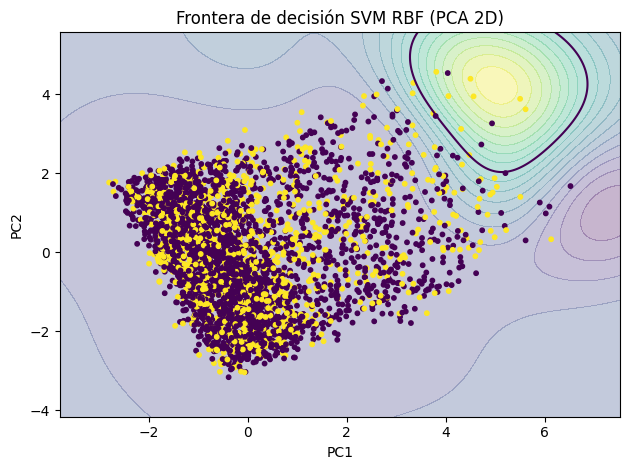

In [ ]:

# 8) Visualización de hiperplanos (PCA 2D ilustrativa)
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)

svm_lin_2d = SVC(kernel="linear", probability=True, random_state=42).fit(X_train_pca, y_train)
svm_rbf_2d = SVC(kernel="rbf",    probability=True, random_state=42).fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min,x_max,400), np.linspace(y_min,y_max,400))

# Linear
Z_lin = svm_lin_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure()
plt.contour(xx, yy, Z_lin, levels=[-1,0,1])
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s=10)
plt.title("Hiperplano SVM lineal (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# RBF
Z_rbf = svm_rbf_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure()
plt.contourf(xx, yy, Z_rbf, levels=20, alpha=0.3)
plt.contour(xx, yy, Z_rbf, levels=[0])
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s=10)
plt.title("Frontera de decisión SVM RBF (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


## Notas y sugerencias
- El dataset puede estar desbalanceado (más 0s que 1s en `CreditCard`), por lo que métricas como **Recall**, **F1** y **ROC-AUC** son más informativas que solo Accuracy.
- Para mejorar rendimiento se recomienda:
  - Usar `class_weight='balanced'` en SVC.
  - Ajustar hiperparámetros (`C`, `gamma`, `degree`) con `GridSearchCV`.
  - Probar métricas como **Precision-Recall AUC** en lugar de solo ROC AUC.

### Cómo cada SVM encuentra el “mejor hiperplano”
- **Linear:** Busca el hiperplano que **maximiza el margen** entre clases. Funciona bien si los datos son separables de forma casi lineal.

  ¿Qué es el margen?

  Imagina que tienes dos grupos de puntos en un plano (clase 0 y clase 1).

  Un hiperplano (en 2D sería una línea) es la frontera que separa ambos grupos.

  El margen es la distancia desde ese hiperplano hasta los puntos más cercanos de cada clase.

  Esos puntos más cercanos se llaman vectores soporte (support vectors).

  ¿Qué significa “maximizar” el margen?

  Podríamos dibujar muchas líneas que separan a los dos grupos (si los datos son separables).

  Pero algunas líneas estarían “apretadas” contra un grupo, lo que hace que pequeños cambios en los datos puedan causar errores.

  El SVM elige la línea (hiperplano) que deja el mayor espacio posible entre las clases → es decir, el máximo margen.

  Intuitivamente: cuanto más lejos estén los puntos de la frontera, más “seguro” está el modelo de sus predicciones.


- **RBF (Gaussian):** Usa un kernel radial que mide similitud en torno a cada punto. **Proyecta los datos a un espacio de alta dimensión** para separarlos linealmente ahí. Ideal para fronteras no lineales.
- **Polynomial:** Genera combinaciones polinómicas de las features. Captura relaciones más complejas y curvas en la frontera, aunque puede sobreajustar si el grado es alto.
- **Sigmoid:** Similar a una neurona de red neuronal con activación logística. Tiende a ser menos estable y se usa poco en práctica.

En general, **RBF** y **Polynomial** suelen dar los mejores resultados en problemas con fronteras no lineales.